In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
df = pd.read_csv("../data/creditcard.csv")


In [7]:
df.head()

,transaction_amount,transaction_time,customer_age,merchant_id,customer_location,is_fraud
0,375.17,21,44,1044,17,0
1,950.76,16,51,1095,8,0
2,732.26,8,44,1061,15,0
3,599.06,0,34,1092,8,0
4,156.86,20,60,1057,17,0


In [10]:
df.shape


(500, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_amount  500 non-null    float64
 1   transaction_time    500 non-null    int64  
 2   customer_age        500 non-null    int64  
 3   merchant_id         500 non-null    int64  
 4   customer_location   500 non-null    int64  
 5   is_fraud            500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [12]:
df.describe()

,transaction_amount,transaction_time,customer_age,merchant_id,customer_location,is_fraud
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,499.063160,11.10800,44.114000,1049.332000,9.798000,0.136000
std,298.389795,7.08157,14.857405,29.178495,5.458276,0.343132
min,6.060000,0.00000,18.000000,1000.000000,1.000000,0.000000
25%,242.037500,5.00000,32.000000,1025.000000,5.000000,0.000000
50%,513.650000,11.00000,44.000000,1048.000000,10.000000,0.000000
75%,756.372500,17.00000,57.000000,1075.000000,14.250000,0.000000
max,992.970000,23.00000,69.000000,1099.000000,19.000000,1.000000


In [14]:
df.isnull().sum()

transaction_amount    0
transaction_time      0
customer_age          0
merchant_id           0
customer_location     0
is_fraud              0
dtype: int64

In [20]:
print(df.columns)

Index(['transaction_amount', 'transaction_time', 'customer_age', 'merchant_id',
       'customer_location', 'is_fraud'],
      dtype='object')


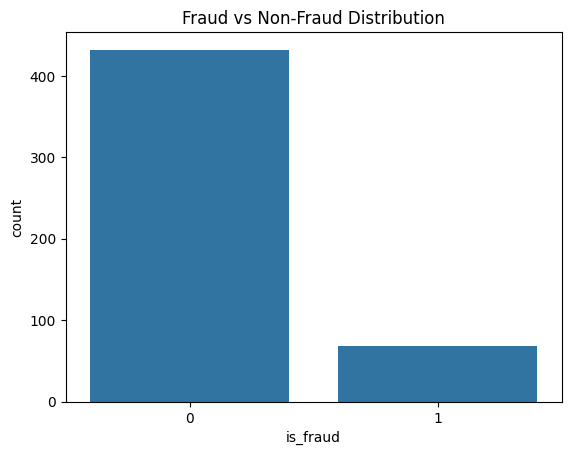

is_fraud
0    432
1     68
Name: count, dtype: int64
is_fraud
0    86.4
1    13.6
Name: proportion, dtype: float64


In [21]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True)*100)

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        86
           1       0.63      0.86      0.73        14

    accuracy                           0.91       100
   macro avg       0.80      0.89      0.84       100
weighted avg       0.93      0.91      0.92       100

Confusion Matrix:
 [[79  7]
 [ 2 12]]
ROC-AUC: 0.9551495016611296


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("confusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_scaled))
print("ROC-AUC:", roc_auc_score(y_test, model_scaled.predict_proba(X_test_scaled)[:,1]))

confusion Matrix:
 [[83  3]
 [ 7  7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94        86
           1       0.70      0.50      0.58        14

    accuracy                           0.90       100
   macro avg       0.81      0.73      0.76       100
weighted avg       0.89      0.90      0.89       100

ROC-AUC: 0.9526578073089701


In [28]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = model_balanced.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, model_balanced.predict_proba(X_test_scaled)[:,1]))

Confusion Matrix:
 [[72 14]
 [ 1 13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91        86
           1       0.48      0.93      0.63        14

    accuracy                           0.85       100
   macro avg       0.73      0.88      0.77       100
weighted avg       0.92      0.85      0.87       100

ROC-AUC: 0.951827242524917


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Confusion Matrix:
 [[80  6]
 [ 4 10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        86
           1       0.62      0.71      0.67        14

    accuracy                           0.90       100
   macro avg       0.79      0.82      0.80       100
weighted avg       0.91      0.90      0.90       100

ROC-AUC: 0.9580564784053156


In [30]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic (Baseline)",
        "Logistic + Scaling",
        "Logistic + Balanced",
        "Random Forest"
    ],
    "Recall (Fraud)": [
        0.86,
        0.50,
        0.93,
        0.71
    ],
    "Precision (Fraud)": [
        0.63,
        0.70,
        0.48,
        0.62
    ]
})

results

,Model,Recall (Fraud),Precision (Fraud)
0,Logistic (Baseline),0.86,0.63
1,Logistic + Scaling,0.50,0.70
2,Logistic + Balanced,0.93,0.48
3,Random Forest,0.71,0.62


In [32]:
y_probs = model.predict_proba(X_test)[:, 1]
print(y_probs)

[3.68842560e-02 1.13800606e-05 3.65538380e-02 5.50715742e-06
 2.81203285e-02 9.75788513e-06 1.80301732e-01 3.88365447e-04
 6.43530042e-06 6.41000686e-01 8.71821374e-01 8.85900593e-01
 1.71707893e-05 6.14619175e-01 8.49105162e-03 3.62767139e-03
 5.55486677e-06 2.42988594e-04 3.23216865e-05 2.43250180e-04
 1.44634320e-03 2.85804085e-04 6.13483347e-05 1.02846387e-04
 2.53946922e-04 5.26273904e-01 1.00622257e-01 3.63930865e-05
 2.24561181e-01 2.81792652e-06 2.88741856e-05 1.63435595e-01
 6.39054458e-01 7.47390370e-03 1.46001676e-05 3.20799413e-02
 6.42501454e-02 5.94913951e-01 1.95716690e-01 1.54383810e-05
 2.15024779e-04 1.44917339e-05 2.64402638e-05 2.24326263e-04
 4.85784913e-01 3.09259469e-06 8.23970757e-05 5.06130348e-04
 4.49961162e-06 2.92294065e-05 1.07524521e-01 5.12507486e-01
 1.96686775e-01 7.36358324e-01 6.48191109e-01 7.34213592e-01
 1.22018706e-04 3.81099515e-02 2.42076698e-05 4.49453829e-03
 2.66624597e-03 1.18170672e-02 8.75545735e-04 3.79727688e-04
 5.30598814e-03 8.796419

In [33]:
import numpy as np

threshold = 0.3  # try 0.3, 0.4, 0.6, 0.7
y_pred_custom = (y_probs >= threshold).astype(int)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print("Threshold:", threshold)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Threshold: 0.3
Confusion Matrix:
 [[75 11]
 [ 1 13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93        86
           1       0.54      0.93      0.68        14

    accuracy                           0.88       100
   macro avg       0.76      0.90      0.81       100
weighted avg       0.92      0.88      0.89       100



In [35]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_custom = (y_probs >= threshold).astype(int)
    print("\nThreshold:", threshold)
    print("Recall:", classification_report(y_test, y_pred_custom, output_dict=True)['1']['recall'])
    print("Precision:", classification_report(y_test, y_pred_custom, output_dict=True)['1']['precision'])


Threshold: 0.3
Recall: 0.9285714285714286
Precision: 0.5416666666666666

Threshold: 0.4
Recall: 0.8571428571428571
Precision: 0.6

Threshold: 0.5
Recall: 0.8571428571428571
Precision: 0.631578947368421

Threshold: 0.6
Recall: 0.7142857142857143
Precision: 0.7142857142857143

Threshold: 0.7
Recall: 0.42857142857142855
Precision: 0.6666666666666666


In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_model = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    log_model,
    param_grid,
    cv=5,
    scoring='recall',   # IMPORTANT
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall Score:", grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall Score: 0.6145454545454545


In [37]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1]))

Confusion Matrix:
 [[82  4]
 [ 4 10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        86
           1       0.71      0.71      0.71        14

    accuracy                           0.92       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.92      0.92      0.92       100

ROC-AUC: 0.9551495016611296


In [38]:
y_probs_best = best_model.predict_proba(X_test_scaled)[:, 1]

In [39]:
import numpy as np

final_threshold = 0.3
y_pred_final = (y_probs_best >= final_threshold).astype(int)

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Final Threshold:", final_threshold)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_probs_best))

Final Threshold: 0.3
Confusion Matrix:
 [[78  8]
 [ 2 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        86
           1       0.60      0.86      0.71        14

    accuracy                           0.90       100
   macro avg       0.79      0.88      0.82       100
weighted avg       0.92      0.90      0.91       100

ROC-AUC: 0.9551495016611296


In [41]:
import pickle

# Save model
with open("../backend/fraud_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("../backend/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)